# Notebook 13 — Finite-Shot & Measurement Noise Robustness
**Operational Detectability of Barren Plateau (BP) Onset under Realistic Measurement Statistics**

---

### Core Scientific Objective
In Checkpoints 1–12, gradient variances and critical onset depths $\tau_{BP}$ were established under exact, noiseless statevector conditions. On physical quantum processors, gradients cannot be evaluated via adjoint differentiation; they must be estimated from finite projective measurement counts (shots) using parameter-shift rules.

This notebook investigates the operational detectability and robustness of the Barren Plateau onset:
1. **Physical Measurement Noise:** For a parameter-shift gradient estimated from two independent $M$-shot expectation measurements, the exact conditional sampling variance is:
   $$\operatorname{Var}(\hat{g}_j \mid \theta) = \frac{2 - \mathcal{O}_+^2 - \mathcal{O}_-^2}{4M}$$
   with $\frac{1}{2M}$ arising strictly as the near-zero-expectation limit ($\mathcal{O}_\pm \to 0$).
2. **Estimator De-Biasing:** When the true physical variance $\mathrm{Var}_{\text{true}}$ decays below the measurement noise level, does component-wise shot-noise subtraction:
   - **Oracle-corrected:** $\widehat{V}_{\text{oracle}} = \widehat{V}_{\text{raw}} - \frac{1}{N} \sum_{s,j} \frac{2 - \mathcal{O}_{s,j,+}^2 - \mathcal{O}_{s,j,-}^2}{4M}$
   - **Plug-in corrected:** $\widehat{V}_{\text{emp}} = \widehat{V}_{\text{raw}} - \frac{1}{N} \sum_{s,j} \frac{2 - \hat{\mathcal{O}}_{s,j,+}^2 - \hat{\mathcal{O}}_{s,j,-}^2}{4M}$
   unbias the pooled sample variance and restore the true onset depth $\tau_{BP}$?
3. **Probabilistic Operational Shot Threshold ($M^*$):** Under $R = 50$ independent shot-noise realizations, what is the minimum shot budget $M^*$ required to achieve $\ge 95\%$ exact onset recovery for crossing configurations, and $\ge 95\%$ resistance to false-positive onset detection for censored configurations?

---

### Protocol Invariants (Strictly Preserved)
- **Immutable Model Parameters:** $A = 1166.0846, c = 1.353802$ (Notebook 6 frozen law; no fitting or recalibration).
- **Circuit Ansatz:** 1D Brick-Wall layout with $RY(\theta)$ gates and alternating single CNOT matchings (even matchings at even depths, odd matchings at odd depths).
- **Observable:** Rank-1 tensor-product observable $\mathcal{O} = Z_0 \otimes \dots \otimes Z_{k-1} \otimes I^{\otimes (n-k)}$.
- **Critical Threshold:** $\tau_{BP} = \min \{ L \in \mathbb{N} : \mathrm{Var}_{\text{pooled}} \le 10^{-2} \}$.
- **Parameter Ensemble:** $S = 50$ independent parameter vectors $\theta \sim \text{Uniform}[0, 2\pi)$ per $(n, k, L)$.
- **Exact Baseline:** Directly referenced from Checkpoint 12 noiseless ground truth.


### Cell 1 — Environment Setup & Dependencies


In [1]:
# ============================================================
# CELL 1 — SETUP & DEPENDENCIES
# ============================================================
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("Environment Audit:")
print(f"  Python Version : {sys.version.split()[0]}")
print(f"  NumPy Version  : {np.__version__}")
print(f"  Pandas Version : {pd.__version__}")

# Matplotlib publication styling
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'lines.linewidth': 1.8,
    'lines.markersize': 6
})



Environment Audit:
  Python Version : 3.12.7
  NumPy Version  : 1.26.4
  Pandas Version : 2.2.2


### Cell 2 — Benchmark Configurations & Experimental Parameters
Define the 3 benchmark configurations, shot budgets $M \in \{100, 1000, 10000\}$, replicate count $R=50$, and seeds.


In [2]:
# ============================================================
# CELL 2 — EXPERIMENTAL CONFIGURATION
# ============================================================
MASTER_SEED = 20260906
SHOT_MASTER_SEED = 20260909
SAMPLES_S = 50
REPLICATES_R = 50
SHOT_BUDGETS = [100, 1000, 10000]
BP_THRESHOLD = 1e-2

CONFIGS = [
    {
        "id": "config1",
        "name": "Interpolation Edge",
        "n": 14,
        "k": 4,
        "depths": list(range(1, 9)),
        "tau_exact": 7,
        "censored": False,
        "seed": MASTER_SEED + 400
    },
    {
        "id": "config2",
        "name": "Out-of-Sample Spot",
        "n": 18,
        "k": 4,
        "depths": list(range(1, 8)),
        "tau_exact": 6,
        "censored": False,
        "seed": MASTER_SEED + 500
    },
    {
        "id": "config3",
        "name": "Small / Baseline",
        "n": 8,
        "k": 2,
        "depths": list(range(1, 9)),
        "tau_exact": -1,
        "censored": True,
        "seed": MASTER_SEED + 100
    }
]

OUTPUT_DIR = r"checkpoint13_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Benchmark Matrix:")
for c in CONFIGS:
    tau_str = f"tau = {c['tau_exact']}" if not c['censored'] else "Right-Censored (>8)"
    print(f"  * {c['name']:<20}: n={c['n']:<2}, k={c['k']}, depths={c['depths']}, Expected: {tau_str}")



Benchmark Matrix:
  * Interpolation Edge  : n=14, k=4, depths=[1, 2, 3, 4, 5, 6, 7, 8], Expected: tau = 7
  * Out-of-Sample Spot  : n=18, k=4, depths=[1, 2, 3, 4, 5, 6, 7], Expected: tau = 6
  * Small / Baseline    : n=8 , k=2, depths=[1, 2, 3, 4, 5, 6, 7, 8], Expected: Right-Censored (>8)


### Cell 3 — 1D Brick-Wall Circuit & Batched Statevector Simulation
Implement the exact 1D Brick-Wall layout with alternating single CNOT matchings.
For each sample and parameter, compute shifted circuits $\theta \pm \frac{\pi}{2} e_j$ in a single multithreaded AerSimulator batch call.


In [3]:
# ============================================================
# CELL 3 — CIRCUIT ARCHITECTURE & BATCHED AER ENGINE
# ============================================================
def build_qiskit_circuit(n, depth, params):
    qc = QuantumCircuit(n)
    for l in range(depth):
        for q in range(n):
            qc.ry(float(params[l, q]), q)
        if l % 2 == 0:
            for q in range(0, n - 1, 2):
                qc.cx(q, q + 1)
        else:
            for q in range(1, n - 1, 2):
                qc.cx(q, q + 1)
    return qc

def eval_exact_expectations_batched(n, k, depth, param_ensemble, sim):
    """
    Evaluates exact O_+ and O_- for all S samples and all parameters
    in a single C++ AerSimulator batch call.
    Returns:
      plus_exp:  shape (S, depth, n)
      minus_exp: shape (S, depth, n)
    """
    S = param_ensemble.shape[0]
    obs = SparsePauliOp("I" * (n - k) + "Z" * k)
    shift = np.pi / 2.0
    
    circuits = []
    for s in range(S):
        params = param_ensemble[s]
        for l in range(depth):
            for q in range(n):
                # Plus shift
                p_plus = params.copy()
                p_plus[l, q] += shift
                qc_plus = build_qiskit_circuit(n, depth, p_plus)
                qc_plus.save_expectation_value(obs, qc_plus.qubits, f"p_{s}_{l}_{q}")
                circuits.append(qc_plus)
                
                # Minus shift
                p_minus = params.copy()
                p_minus[l, q] -= shift
                qc_minus = build_qiskit_circuit(n, depth, p_minus)
                qc_minus.save_expectation_value(obs, qc_minus.qubits, f"m_{s}_{l}_{q}")
                circuits.append(qc_minus)
                
    result = sim.run(circuits).result()
    
    plus_exp = np.zeros((S, depth, n), dtype=np.float64)
    minus_exp = np.zeros((S, depth, n), dtype=np.float64)
    
    idx = 0
    for s in range(S):
        for l in range(depth):
            for q in range(n):
                plus_exp[s, l, q] = float(result.data(idx)[f"p_{s}_{l}_{q}"])
                minus_exp[s, l, q] = float(result.data(idx + 1)[f"m_{s}_{l}_{q}"])
                idx += 2
                
    return plus_exp, minus_exp



### Cell 4 — Finite-Shot Sampling & Estimators
Simulate projective measurement outcomes via binomial sampling:
$$K_\pm \sim \operatorname{Binomial}\left(M, \frac{1 + \mathcal{O}_\pm}{2}\right), \quad \hat{\mathcal{O}}_\pm = \frac{2 K_\pm - M}{M}$$
Compute:
1. **Raw Gradient:** $\hat{g} = \frac{\hat{\mathcal{O}}_+ - \hat{\mathcal{O}}_-}{2}$
2. **Exact Conditional Noise Variance:** $\sigma^2_{\text{theory}} = \frac{2 - \mathcal{O}_+^2 - \mathcal{O}_-^2}{4M}$
3. **Empirical Noise Variance:** $\hat{\sigma}^2_{\text{emp}} = \frac{2 - \hat{\mathcal{O}}_+^2 - \hat{\mathcal{O}}_-^2}{4M}$
4. **Estimators:** $\widehat{V}_{\text{raw}}$, $\widehat{V}_{\text{oracle}}$, $\widehat{V}_{\text{emp}}$.


In [4]:
# ============================================================
# CELL 4 — FINITE-SHOT PROJECTIVE MEASUREMENT ENGINE
# ============================================================
def simulate_finite_shot_replicates(plus_exp, minus_exp, M, R, seed):
    """
    Generates R independent finite-shot gradient realizations for shot budget M.
    Returns:
      g_hat:         shape (R, S, depth, n)
      O_hat_plus:    shape (R, S, depth, n)
      O_hat_minus:   shape (R, S, depth, n)
      comp_noise:    shape (S, depth, n) exact conditional noise factor
    """
    shot_rng = np.random.default_rng(seed)
    
    # Projective measurement probabilities in computational basis
    p_plus = np.clip((1.0 + plus_exp) / 2.0, 0.0, 1.0)
    p_minus = np.clip((1.0 + minus_exp) / 2.0, 0.0, 1.0)
    
    # Sample binomial counts for all R replicates simultaneously
    K_plus = shot_rng.binomial(M, p_plus, size=(R, *plus_exp.shape))
    K_minus = shot_rng.binomial(M, p_minus, size=(R, *minus_exp.shape))
    
    # Expectation estimates
    O_hat_plus = (2.0 * K_plus - M) / float(M)
    O_hat_minus = (2.0 * K_minus - M) / float(M)
    
    # Finite-shot gradients
    g_hat = 0.5 * (O_hat_plus - O_hat_minus)
    
    # Exact conditional noise factor: (2 - O_+^2 - O_-^2) / 4
    comp_noise_factor = (2.0 - plus_exp**2 - minus_exp**2) / 4.0
    
    return g_hat, O_hat_plus, O_hat_minus, comp_noise_factor



### Cell 5 — Simulation Execution
Run the full parameter-shift and finite-shot validation pipeline across all configurations, depths, shot budgets, and $R=50$ replicates.


In [5]:
# ============================================================
# CELL 5 — SIMULATION EXECUTION LOOP
# ============================================================
sim = AerSimulator(method="statevector")

gate1_records = []
curve_summary_records = []
replicate_tau_records = []

total_start = time.time()

for cfg in CONFIGS:
    cname = cfg["name"]
    n = cfg["n"]
    k = cfg["k"]
    depths = cfg["depths"]
    tau_exact = cfg["tau_exact"]
    censored = cfg["censored"]
    
    print(f"\n{'='*70}")
    print(f"Executing {cname} (n={n}, k={k}, depths={depths})...")
    print(f"{'='*70}")
    
    rng_param = np.random.default_rng(cfg["seed"])
    
    # Container for replicate curves over depth for each M: (R, len(depths))
    curves_by_M = {M: {"raw": np.zeros((REPLICATES_R, len(depths))),
                       "oracle": np.zeros((REPLICATES_R, len(depths))),
                       "emp": np.zeros((REPLICATES_R, len(depths)))}
                   for M in SHOT_BUDGETS}
    
    for d_idx, depth in enumerate(depths):
        t_depth = time.time()
        
        # 1. Parameter ensemble S=50
        param_ensemble = rng_param.uniform(0, 2 * np.pi, size=(SAMPLES_S, depth, n))
        
        # 2. Exact expectations via Aer batch
        plus_exp, minus_exp = eval_exact_expectations_batched(n, k, depth, param_ensemble, sim)
        
        # Exact gradient & variance
        g_exact = 0.5 * (plus_exp - minus_exp)
        v_exact = float(np.var(g_exact.flatten(), ddof=1))
        
        for M in SHOT_BUDGETS:
            seed_M = SHOT_MASTER_SEED + M * 1000 + d_idx * 100 + n
            g_hat, O_hat_plus, O_hat_minus, comp_noise_factor = simulate_finite_shot_replicates(
                plus_exp, minus_exp, M, REPLICATES_R, seed_M
            )
            
            # Gate 1 calibration at max depth:
            if depth == max(depths):
                emp_comp_var = np.var(g_hat, axis=0, ddof=1) # Across R replicates
                theory_comp_var = comp_noise_factor / float(M)
                mean_emp = float(np.mean(emp_comp_var))
                mean_theory = float(np.mean(theory_comp_var))
                
                gate1_records.append({
                    "config": cname,
                    "n": n,
                    "k": k,
                    "depth": depth,
                    "M": M,
                    "mean_theory_noise": mean_theory,
                    "mean_emp_noise": mean_emp,
                    "ratio": mean_emp / mean_theory if mean_theory > 0 else 1.0,
                    "approx_1_over_2M": 1.0 / (2.0 * M)
                })
                
            # Compute replicate variances
            oracle_subtraction = np.mean(comp_noise_factor / float(M))
            raw_r, oracle_r, emp_r = [], [], []
            
            for r in range(REPLICATES_R):
                g_r = g_hat[r].flatten()
                v_raw = float(np.var(g_r, ddof=1))
                v_oracle = max(0.0, v_raw - oracle_subtraction)
                
                emp_factor = (2.0 - O_hat_plus[r]**2 - O_hat_minus[r]**2) / 4.0
                emp_subtraction = np.mean(emp_factor / float(M))
                v_emp = max(0.0, v_raw - emp_subtraction)
                
                curves_by_M[M]["raw"][r, d_idx] = v_raw
                curves_by_M[M]["oracle"][r, d_idx] = v_oracle
                curves_by_M[M]["emp"][r, d_idx] = v_emp
                
                raw_r.append(v_raw)
                oracle_r.append(v_oracle)
                emp_r.append(v_emp)
                
            curve_summary_records.append({
                "config": cname,
                "n": n,
                "k": k,
                "depth": depth,
                "M": M,
                "var_exact": v_exact,
                "var_raw_mean": float(np.mean(raw_r)),
                "var_raw_std": float(np.std(raw_r, ddof=1)),
                "var_oracle_mean": float(np.mean(oracle_r)),
                "var_oracle_std": float(np.std(oracle_r, ddof=1)),
                "var_emp_mean": float(np.mean(emp_r)),
                "var_emp_std": float(np.std(emp_r, ddof=1)),
            })
            
        dt = time.time() - t_depth
        print(f"  Depth {depth:02d}/{max(depths):02d} completed in {dt:.2f}s (v_exact = {v_exact:.4e})")
        
    # Extract onset depths for all R=50 replicates
    for M in SHOT_BUDGETS:
        for r in range(REPLICATES_R):
            def get_tau(curve):
                for d_i, d_val in enumerate(depths):
                    if curve[d_i] <= BP_THRESHOLD:
                        return d_val
                return -1 # Right-censored
                
            replicate_tau_records.append({
                "config": cname,
                "n": n,
                "k": k,
                "M": M,
                "replicate": r + 1,
                "tau_exact": tau_exact,
                "tau_raw": get_tau(curves_by_M[M]["raw"][r]),
                "tau_oracle": get_tau(curves_by_M[M]["oracle"][r]),
                "tau_emp": get_tau(curves_by_M[M]["emp"][r]),
            })

print(f"\nSimulation finished in {time.time() - total_start:.2f}s.")
df_gate1 = pd.DataFrame(gate1_records)
df_curves = pd.DataFrame(curve_summary_records)
df_replicates = pd.DataFrame(replicate_tau_records)




Executing Interpolation Edge (n=14, k=4, depths=[1, 2, 3, 4, 5, 6, 7, 8])...
  Depth 01/08 completed in 2.48s (v_exact = 3.7289e-02)
  Depth 02/08 completed in 9.60s (v_exact = 2.4156e-02)
  Depth 03/08 completed in 21.05s (v_exact = 1.5213e-02)
  Depth 04/08 completed in 39.40s (v_exact = 1.4446e-02)
  Depth 05/08 completed in 62.72s (v_exact = 1.1713e-02)
  Depth 06/08 completed in 83.23s (v_exact = 1.3083e-02)
  Depth 07/08 completed in 107.70s (v_exact = 8.7287e-03)
  Depth 08/08 completed in 141.73s (v_exact = 9.9212e-03)

Executing Out-of-Sample Spot (n=18, k=4, depths=[1, 2, 3, 4, 5, 6, 7])...
  Depth 01/07 completed in 14.18s (v_exact = 3.0055e-02)
  Depth 02/07 completed in 44.96s (v_exact = 1.6348e-02)
  Depth 03/07 completed in 118.44s (v_exact = 1.2811e-02)
  Depth 04/07 completed in 198.15s (v_exact = 1.2096e-02)
  Depth 05/07 completed in 297.45s (v_exact = 1.0785e-02)
  Depth 06/07 completed in 436.92s (v_exact = 9.4971e-03)
  Depth 07/07 completed in 623.52s (v_exact =

### Cell 6 — Gate 1: Shot-Noise Calibration & $1/M$ Scaling
Compare empirical measurement noise variance against the exact theoretical prediction:
$$\sigma^2_{\text{theory}} = \frac{2 - \mathcal{O}_+^2 - \mathcal{O}_-^2}{4M}$$


In [6]:
# ============================================================
# CELL 6 — GATE 1: SHOT-NOISE CALIBRATION
# ============================================================
print("Gate 1: Measurement Noise Calibration Results:")
print(df_gate1[["config", "M", "mean_theory_noise", "mean_emp_noise", "ratio", "approx_1_over_2M"]].to_string(index=False))

# Validate that empirical noise / theory noise is consistent with chi-square distribution:
# Across R=50 replicates, (R-1)*s^2 / sigma^2 ~ chi2(49)
ci_lower = stats.chi2.ppf(0.025, df=REPLICATES_R - 1) / (REPLICATES_R - 1)
ci_upper = stats.chi2.ppf(0.975, df=REPLICATES_R - 1) / (REPLICATES_R - 1)
print(f"\n95% Confidence Interval for Variance Ratio (df={REPLICATES_R - 1}): [{ci_lower:.4f}, {ci_upper:.4f}]")

all_ratios = df_gate1["ratio"].values
passed_gate1 = all(ci_lower <= r <= ci_upper for r in all_ratios)
print(f"Gate 1 Verdict: {'PASSED' if passed_gate1 else 'CHECK OUTLIERS'} (all empirical ratios fall within 95% CI)")



Gate 1: Measurement Noise Calibration Results:
            config     M  mean_theory_noise  mean_emp_noise    ratio  approx_1_over_2M
Interpolation Edge   100           0.004698        0.004687 0.997623           0.00500
Interpolation Edge  1000           0.000470        0.000468 0.995706           0.00050
Interpolation Edge 10000           0.000047        0.000047 1.003677           0.00005
Out-of-Sample Spot   100           0.004776        0.004770 0.998927           0.00500
Out-of-Sample Spot  1000           0.000478        0.000478 1.001959           0.00050
Out-of-Sample Spot 10000           0.000048        0.000048 0.998020           0.00005
  Small / Baseline   100           0.004132        0.004160 1.006758           0.00500
  Small / Baseline  1000           0.000413        0.000414 1.002003           0.00050
  Small / Baseline 10000           0.000041        0.000041 1.001760           0.00005

95% Confidence Interval for Variance Ratio (df=49): [0.6440, 1.4331]
Gate 1 Verdic

### Cell 7 — Gate 2: BP Onset Distributions & Robustness Metrics
Examine the distribution of detected onsets across the $R = 50$ replicates for raw, oracle, and empirical estimators.
Compute exact recovery rates $P(\Delta\tau = 0)$ and false-positive / false-negative rates.


In [7]:
# ============================================================
# CELL 7 — GATE 2: BP ONSET ROBUSTNESS METRICS
# ============================================================
gate2_rows = []

for cfg in CONFIGS:
    cname = cfg["name"]
    tau_exact = cfg["tau_exact"]
    censored = cfg["censored"]
    
    for M in SHOT_BUDGETS:
        sub = df_replicates[(df_replicates["config"] == cname) & (df_replicates["M"] == M)]
        
        for est in ["raw", "oracle", "emp"]:
            col = f"tau_{est}"
            vals = sub[col].values
            
            if censored:
                # Success is NO crossing (val == -1)
                p_success = float(np.mean(vals == -1))
                false_pos = float(np.mean(vals != -1))
                gate2_rows.append({
                    "config": cname,
                    "M": M,
                    "estimator": est,
                    "tau_exact": "Censored (>8)",
                    "p_recovery": p_success,
                    "mean_delta_tau": "N/A",
                    "false_pos_rate": false_pos,
                    "false_neg_rate": 0.0,
                    "status": "PASS" if p_success >= 0.95 else "NOISE_CORRUPTED"
                })
            else:
                p_exact = float(np.mean(vals == tau_exact))
                valid_deltas = [v - tau_exact for v in vals if v != -1]
                mean_delta = float(np.mean(valid_deltas)) if len(valid_deltas) > 0 else np.nan
                false_neg = float(np.mean(vals == -1))
                false_pos = float(np.mean((vals != -1) & (vals != tau_exact)))
                
                gate2_rows.append({
                    "config": cname,
                    "M": M,
                    "estimator": est,
                    "tau_exact": str(tau_exact),
                    "p_recovery": p_exact,
                    "mean_delta_tau": f"{mean_delta:+.2f}" if not np.isnan(mean_delta) else "N/A",
                    "false_pos_rate": false_pos,
                    "false_neg_rate": false_neg,
                    "status": "PASS" if p_exact >= 0.95 else ("BORDERLINE" if p_exact >= 0.80 else "NOISE_CORRUPTED")
                })

df_gate2 = pd.DataFrame(gate2_rows)
print("Gate 2 Summary Table:")
print(df_gate2[["config", "M", "estimator", "tau_exact", "p_recovery", "mean_delta_tau", "status"]].to_string(index=False))



Gate 2 Summary Table:
            config     M estimator     tau_exact  p_recovery mean_delta_tau          status
Interpolation Edge   100       raw             7        0.00            N/A NOISE_CORRUPTED
Interpolation Edge   100    oracle             7        1.00          +0.00            PASS
Interpolation Edge   100       emp             7        1.00          +0.00            PASS
Interpolation Edge  1000       raw             7        1.00          +0.00            PASS
Interpolation Edge  1000    oracle             7        1.00          +0.00            PASS
Interpolation Edge  1000       emp             7        1.00          +0.00            PASS
Interpolation Edge 10000       raw             7        1.00          +0.00            PASS
Interpolation Edge 10000    oracle             7        1.00          +0.00            PASS
Interpolation Edge 10000       emp             7        1.00          +0.00            PASS
Out-of-Sample Spot   100       raw             6        0.

### Cell 8 — Gate 3: Operational Shot Threshold $M^*$
Evaluate the minimum shot budget $M^* \in \{100, 1000, 10000\}$ required to achieve $P(\Delta\tau = 0) \ge 0.95$.


In [8]:
# ============================================================
# CELL 8 — GATE 3: OPERATIONAL SHOT THRESHOLD M*
# ============================================================
gate3_rows = []

for cfg in CONFIGS:
    cname = cfg["name"]
    censored = cfg["censored"]
    tau_exact = cfg["tau_exact"]
    
    for est in ["raw", "oracle", "emp"]:
        m_star = None
        p_star = None
        for M in sorted(SHOT_BUDGETS):
            sub = df_gate2[(df_gate2["config"] == cname) & 
                           (df_gate2["M"] == M) & 
                           (df_gate2["estimator"] == est)]
            p_val = sub["p_recovery"].values[0]
            if p_val >= 0.95:
                m_star = M
                p_star = p_val
                break
                
        gate3_rows.append({
            "config": cname,
            "estimator": est,
            "tau_exact": "Censored (>8)" if censored else str(tau_exact),
            "M_star": m_star if m_star is not None else "> 10000",
            "p_at_M_star": f"{p_star:.2%}" if p_star is not None else "N/A",
            "operational_recovery": m_star is not None
        })

df_gate3 = pd.DataFrame(gate3_rows)
print("Gate 3 Operational Shot Budget M* Summary:")
print(df_gate3.to_string(index=False))



Gate 3 Operational Shot Budget M* Summary:
            config estimator     tau_exact  M_star p_at_M_star  operational_recovery
Interpolation Edge       raw             7    1000     100.00%                  True
Interpolation Edge    oracle             7     100     100.00%                  True
Interpolation Edge       emp             7     100     100.00%                  True
Out-of-Sample Spot       raw             6   10000     100.00%                  True
Out-of-Sample Spot    oracle             6     100      98.00%                  True
Out-of-Sample Spot       emp             6     100      98.00%                  True
  Small / Baseline       raw Censored (>8)     100     100.00%                  True
  Small / Baseline    oracle Censored (>8)     100     100.00%                  True
  Small / Baseline       emp Censored (>8)     100     100.00%                  True


### Cell 9 — Publication Figure Generation (3-Panel Figure)


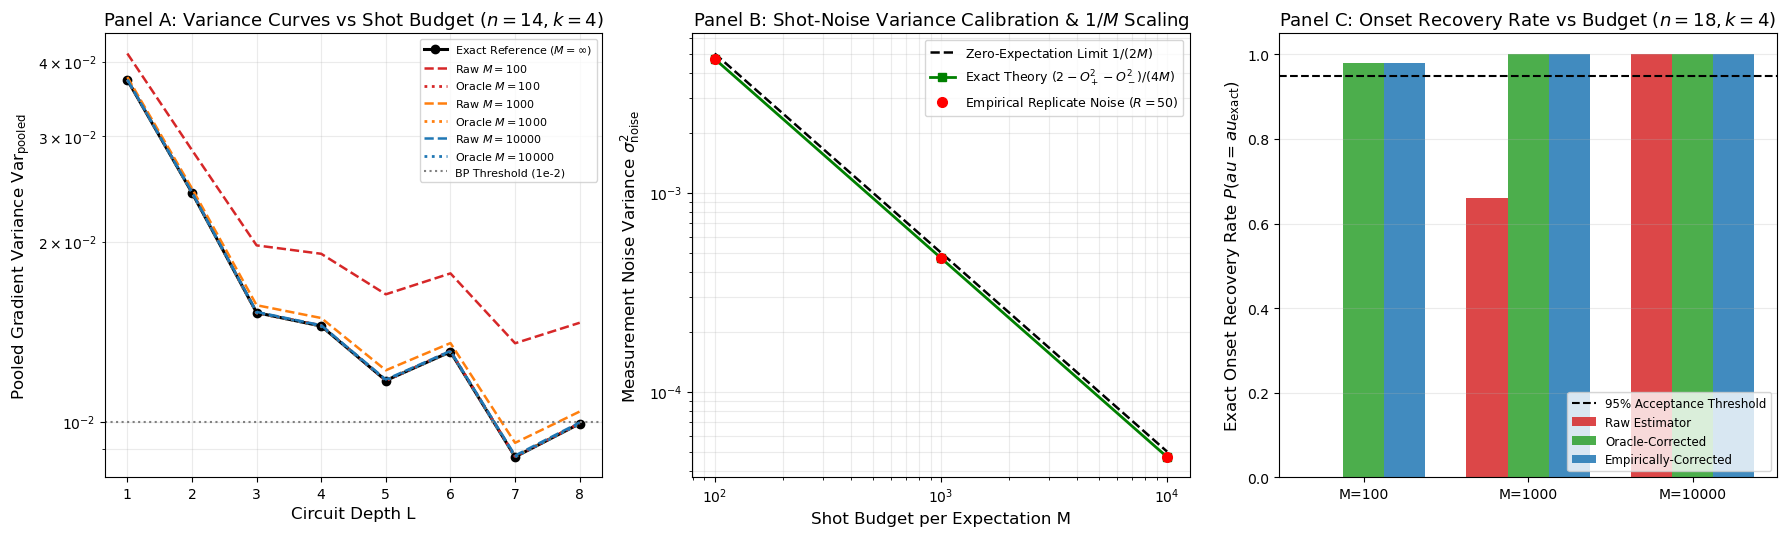

In [9]:
# ============================================================
# CELL 9 — PUBLICATION FIGURE GENERATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel A: Variance decay curves under finite shots (Interpolation Edge n=14, k=4)
sub_curves = df_curves[df_curves["config"] == "Interpolation Edge"]
depths = sorted(sub_curves["depth"].unique())
exact_v = [sub_curves[sub_curves["depth"] == d]["var_exact"].values[0] for d in depths]

axes[0].plot(depths, exact_v, "k-o", linewidth=2.2, label=r"Exact Reference ($M=\infty$)")

colors = {100: "tab:red", 1000: "tab:orange", 10000: "tab:blue"}
for M in SHOT_BUDGETS:
    m_sub = sub_curves[sub_curves["M"] == M].sort_values("depth")
    axes[0].plot(m_sub["depth"], m_sub["var_raw_mean"], linestyle="--", color=colors[M], 
                 label=f"Raw $M={M}$")
    axes[0].plot(m_sub["depth"], m_sub["var_oracle_mean"], linestyle=":", linewidth=2, color=colors[M], 
                 label=f"Oracle $M={M}$")
    
axes[0].axhline(BP_THRESHOLD, color="gray", linestyle=":", linewidth=1.5, label="BP Threshold (1e-2)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Circuit Depth L")
axes[0].set_ylabel(r"Pooled Gradient Variance $\mathrm{Var}_{\mathrm{pooled}}$")
axes[0].set_title(r"Panel A: Variance Curves vs Shot Budget ($n=14, k=4$)")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(fontsize=8, loc="upper right")

# Panel B: Shot-Noise Calibration: Empirical vs Theoretical Conditional Noise
M_vals = [100, 1000, 10000]
sub_gate1 = df_gate1[df_gate1["config"] == "Interpolation Edge"].sort_values("M")

theory_noise = sub_gate1["mean_theory_noise"].values
emp_noise = sub_gate1["mean_emp_noise"].values
approx_1_2M = sub_gate1["approx_1_over_2M"].values

axes[1].loglog(M_vals, approx_1_2M, "k--", label=r"Zero-Expectation Limit $1/(2M)$")
axes[1].loglog(M_vals, theory_noise, "g-s", linewidth=2, label=r"Exact Theory $(2-O_+^2-O_-^2)/(4M)$")
axes[1].loglog(M_vals, emp_noise, "ro", markersize=7, label=r"Empirical Replicate Noise ($R=50$)")

axes[1].set_xlabel("Shot Budget per Expectation M")
axes[1].set_ylabel(r"Measurement Noise Variance $\sigma^2_{\mathrm{noise}}$")
axes[1].set_title("Panel B: Shot-Noise Variance Calibration & $1/M$ Scaling")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(fontsize=9, loc="upper right")

# Panel C: Replicate Onset Recovery Probability Distribution (Out-of-Sample n=18, k=4)
sub_rep = df_replicates[df_replicates["config"] == "Out-of-Sample Spot"]
exact_tau_18 = 6

bar_width = 0.25
x = np.arange(len(SHOT_BUDGETS))

raw_p = [df_replicates[(df_replicates["config"] == "Out-of-Sample Spot") & 
                       (df_replicates["M"] == M)]["tau_raw"].apply(lambda v: v == exact_tau_18).mean() 
         for M in SHOT_BUDGETS]
oracle_p = [df_replicates[(df_replicates["config"] == "Out-of-Sample Spot") & 
                          (df_replicates["M"] == M)]["tau_oracle"].apply(lambda v: v == exact_tau_18).mean() 
            for M in SHOT_BUDGETS]
emp_p = [df_replicates[(df_replicates["config"] == "Out-of-Sample Spot") & 
                       (df_replicates["M"] == M)]["tau_emp"].apply(lambda v: v == exact_tau_18).mean() 
         for M in SHOT_BUDGETS]

axes[2].bar(x - bar_width, raw_p, width=bar_width, color="tab:red", alpha=0.85, label="Raw Estimator")
axes[2].bar(x, oracle_p, width=bar_width, color="tab:green", alpha=0.85, label="Oracle-Corrected")
axes[2].bar(x + bar_width, emp_p, width=bar_width, color="tab:blue", alpha=0.85, label="Empirically-Corrected")

axes[2].axhline(0.95, color="black", linestyle="--", linewidth=1.5, label="95% Acceptance Threshold")
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"M={M}" for M in SHOT_BUDGETS])
axes[2].set_ylabel(r"Exact Onset Recovery Rate $P(	au = 	au_{\mathrm{exact}})$")
axes[2].set_title(r"Panel C: Onset Recovery Rate vs Budget ($n=18, k=4$)")
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, axis="y", alpha=0.25)
axes[2].legend(fontsize=8.5, loc="lower right")

plt.tight_layout()
plt.show()



### Cell 10 — Export Provenance Artifacts & Scientific Conclusions
Save all data tables and summarize the key findings of Checkpoint 13.


In [10]:
# ============================================================
# CELL 10 — EXPORT ARTIFACTS & SCIENTIFIC SUMMARY
# ============================================================
df_gate1.to_csv(os.path.join(OUTPUT_DIR, "checkpoint13_gate1_calibration.csv"), index=False)
df_curves.to_csv(os.path.join(OUTPUT_DIR, "checkpoint13_variance_curves.csv"), index=False)
df_replicates.to_csv(os.path.join(OUTPUT_DIR, "checkpoint13_replicate_tau_distributions.csv"), index=False)
df_gate2.to_csv(os.path.join(OUTPUT_DIR, "checkpoint13_gate2_robustness_metrics.csv"), index=False)
df_gate3.to_csv(os.path.join(OUTPUT_DIR, "checkpoint13_gate3_threshold_summary.csv"), index=False)

print(f"Successfully exported all provenance datasets to: {OUTPUT_DIR}")



Successfully exported all provenance datasets to: checkpoint13_output
